# **Predicción del riesgo de estrés financiero en asalariados de la Comunidad de Madrid**
## **TFM - Máster de Data Science & IA**
### *Pipeline de datos: Silver → Gold*
---

**Fuente de datos:** Encuesta de Condiciones de Vida (ECV) 2025, INE  
**Población objetivo:** Asalariados en activo residentes en la Comunidad de Madrid  
**Resultado de esta capa:** `dataset_analitico.csv` — dataset limpio listo para modelado

---

### *Estructura del notebook*

Este notebook documenta y justifica cada decisión del pipeline de preparación de datos siguiendo la **arquitectura medallón**:

| Capa | Contenido |
|------|-----------|
| 🥉 **Bronze** | Exploración de los datos en crudo tal como los publica el INE |
| 🥈 **Silver** | Limpieza, joins, filtros, imputación, renombrado y decodificación |
| 🥇 **Gold**   | Construcción del target `estres_financiero_alto`, feature engineering y encoding para modelado |  


> **Nota metodológica:** Este notebook reproduce la lógica del script `limpieza_ecv.py` de forma narrativa y exploratoria. El código de producción queda en el script; aquí el objetivo es documentar y visualizar cada decisión para la memoria del TFM.

---

## 0. **Configuración del entorno**

Librerías estándar de análisis de datos. No se requieren dependencias adicionales.

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from pathlib import Path

# from scripts.constants_var import *
from utils.cleaning_utils import cargar_csv
from utils.visualizations_utils import urban_grade_CCMM, PL032_vs_PL040A, dis_target_descod, dis_bar_nuls
from utils.mapeo_utils import VARS_SELECCIONADAS, RENAME_MAP, DECODIFICACIONES

# Estilo visual 
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
})


## 1. **CAPA SILVER - Limpieza y preparación**

La capa Silver transforma los datos en bruto en un dataset analítico limpio y documentado. Cada paso está justificado y acompañado de exploración visual cuando ayuda a entender la decisión.

### S.1 **Joins entre ficheros**


In [3]:
#  Carga de los 4 ficheros originales

df_d = cargar_csv('01_datos_hogar.csv')       # D: datos básicos hogar
df_h = cargar_csv('02_detalles_hogar.csv')    # H: detalle hogar
df_p = cargar_csv('03_detalles_adulto.csv')   # P: datos adulto
df_r = cargar_csv('04_datos_persona.csv')     # R: datos persona

# Join D + H (nivel hogar)
df_hogar = df_d.merge(df_h, left_on='DB030', right_on='HB030', how='inner')

# Join R + P (nivel persona)
df_persona = df_r.merge(df_p, left_on='RB030', right_on='PB030', how='inner')

# Clave hogar derivada desde ID persona
df_persona['id_hogar_join'] = df_persona['RB030'].astype(int) // 100

# Join hogar + persona
df = df_hogar.merge(df_persona, left_on='DB030', right_on='id_hogar_join', how='inner')

print(f"Fichero D:           {df_d.shape[0]:>7,} hogares  × {df_d.shape[1]:>3} variables")
print(f"Fichero H:           {df_h.shape[0]:>7,} hogares  × {df_h.shape[1]:>3} variables")
print(f"Fichero R:           {df_r.shape[0]:>7,} personas × {df_r.shape[1]:>3} variables")
print(f"Fichero P:           {df_p.shape[0]:>7,} personas × {df_p.shape[1]:>3} variables")
print(f"─" * 50)
print(f"Tras join D+H:       {df_hogar.shape[0]:>7,} filas × {df_hogar.shape[1]:>3} columnas")
print(f"Tras join R+P:       {df_persona.shape[0]:>7,} filas × {df_persona.shape[1]:>3} columnas")
print(f"Tras join completo:  {df.shape[0]:>7,} filas × {df.shape[1]:>3} columnas")


Fichero D:            29,369 hogares  ×   9 variables
Fichero H:            29,369 hogares  × 156 variables
Fichero R:            71,398 personas ×  46 variables
Fichero P:            60,825 personas × 245 variables
──────────────────────────────────────────────────
Tras join D+H:        29,369 filas × 165 columnas
Tras join R+P:        60,825 filas × 292 columnas
Tras join completo:   60,825 filas × 457 columnas


**Decisión de diseño - join inner:** Se usa `inner join` en todos los casos porque la ECV garantiza cobertura completa para los hogares y personas de la muestra. El join inner elimina únicamente registros huérfanos (inexistentes en la práctica con microdatos del INE).

### S.2 **Filtro geográfico - Comunidad de Madrid**

El TFM se centra exclusivamente en la Comunidad de Madrid (`DB040 = 'ES30'`). El INE codifica la región a nivel NUTS-2.

> **Limitación metodológica:** El INE no publica la provincia ni el municipio en los microdatos públicos por razones de confidencialidad. El nivel de desagregación geográfica más fino disponible es `DB100` (grado de urbanización), que distingue tres zonas: muy poblada, media y poco poblada.


In [4]:
# Distribución regional antes del filtro
print('Distribución por comunidad autónoma (muestra completa):')
reg_counts = df['DB040'].value_counts().head(10)
print(reg_counts.to_string())
print(f'\nTotal CCAA: {df['DB040'].nunique()}')

# Filtro Madrid
df = df[df['DB040'].astype(str).str.strip() == 'ES30'].copy()
print(f'\nTras filtro Madrid (ES30): {len(df):,} personas')


Distribución por comunidad autónoma (muestra completa):
DB040
ES51    12398
ES61     6843
ES30     6035
ES52     4760
ES11     3362
ES41     3346
ES21     2833
ES62     2512
ES42     2497
ES24     2434

Total CCAA: 19

Tras filtro Madrid (ES30): 6,035 personas


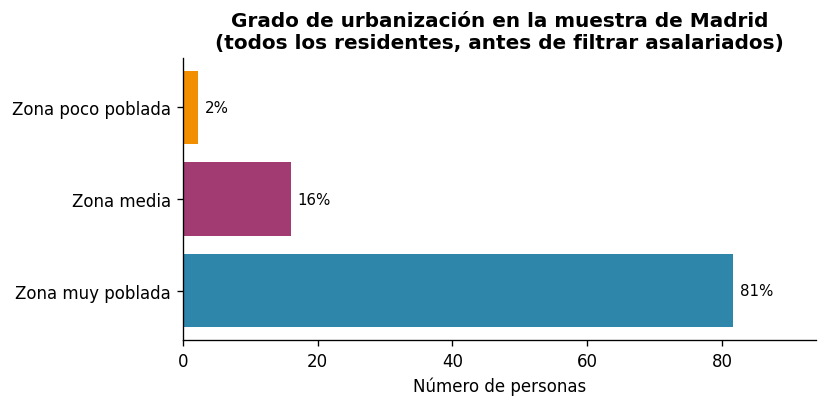

-> La Comunidad de Madrid es eminentemente urbana: el 81% reside en zonas muy pobladas.


In [5]:
# Visualización del grado de urbanización en Madrid (antes de filtrar asalariados)
urb_map = {'1': 'Zona muy poblada', '2': 'Zona media', '3': 'Zona poco poblada'}
urb = df['DB100'].astype(str).str.strip().map(urb_map).value_counts(normalize=True)*100

urban_grade_CCMM(urb)

### S.3 **Filtro de población objetivo - Asalariados en activo**

El estudio se centra en **asalariados que están trabajando en el momento de la encuesta**. Para identificarlos se necesitan dos condiciones simultáneas:

| Variable | Código | Significado |
|----------|--------|-------------|
| `PL032` | `1` | Persona trabajando (situación actividad autodefinida) |
| `PL040A` | `3` | Asalariado en empleo **actual** |

**¿Por qué `PL040A` y no `PL040B`?**  
`PL040B` recoge la situación profesional del **último empleo** y solo tiene valores para personas que ya no trabajan (inactivos o desempleados). Usarla filtraría una población completamente diferente a la de interés.


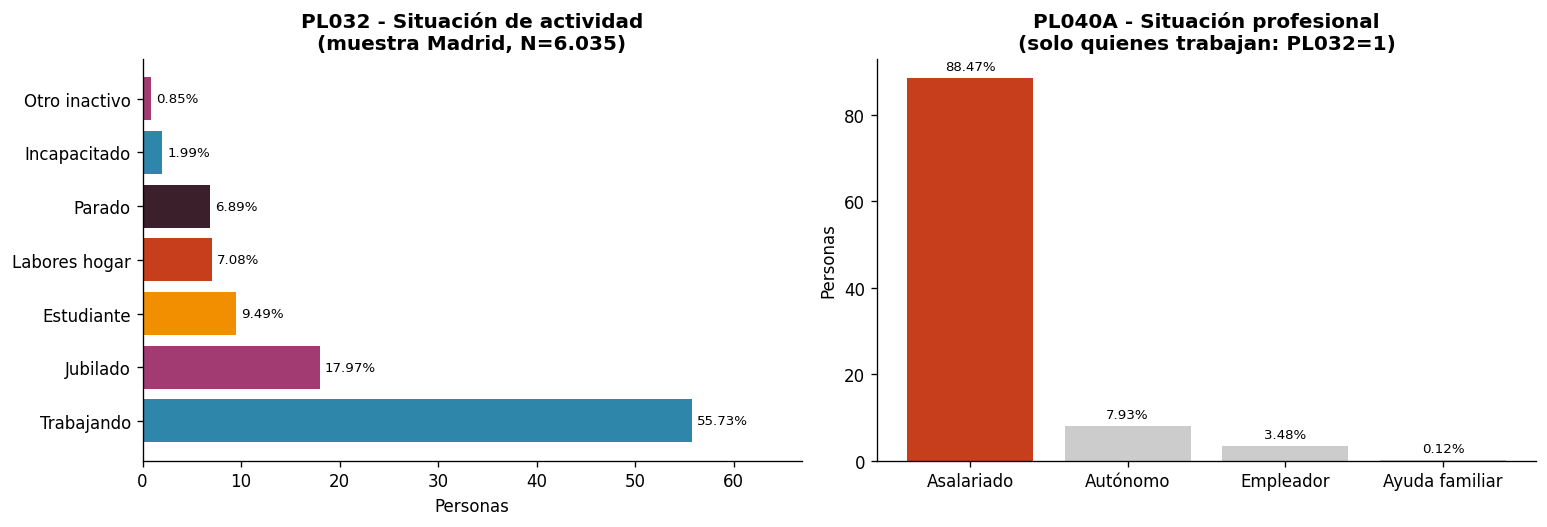

In [6]:
# Distribución de PL032 en Madrid (situación de actividad)
PL032_vs_PL040A(df)


In [7]:
n_antes = len(df)
df = df[
    (df['PL032'].astype(str).str.strip() == '1') &
    (df['PL040A'].astype(str).str.strip() == '3')
].copy()
n_despues = len(df)

print(f"Personas en Madrid (todos):                  {n_antes:>6,}")
print(f"Asalariados en activo (filtro aplicado):     {n_despues:>6,}")
print(f"Excluidos por filtro:                        {n_antes - n_despues:>6,}  ({(n_antes-n_despues)/n_antes*100:.1f}%)")
print(f"\nTamaño final de la muestra analítica: {n_despues:,} asalariados")


Personas en Madrid (todos):                   6,035
Asalariados en activo (filtro aplicado):      2,947
Excluidos por filtro:                         3,088  (51.2%)

Tamaño final de la muestra analítica: 2,947 asalariados


### S.4 **Selección de variables**

Tras una exhaustiva investigación de todas las variables en base a la documentación etraída de cada CSV, se seleccionan **64 variables** de las 457 disponibles tras los joins. El criterio de selección prioriza:

1. **Valor predictivo** para el estrés financiero (rentas, empleo, cargas)
2. **No redundancia** (se excluyen rentas brutas cuando existe la neta)
3. **No granularidad excesiva** (se excluyen `PL211*` — meses por situación mes a mes — con alta correlación interna)
4. **Flags `_F`** se incluyen temporalmente para imputar nulos y se eliminan tras usarlos

A continuación se muestra el inventario por grupos:


In [8]:
# Lista de variables seleccionadas en mapeo_utils.py (misma que en limpieza_ecv.py)

# Mantener solo las que existen
vars_ok = [v for v in VARS_SELECCIONADAS if v in df.columns]
vars_faltantes = [v for v in VARS_SELECCIONADAS if v not in df.columns]

df = df[vars_ok].copy()
n_flags = sum(1 for v in vars_ok if v.endswith('_F'))
n_sustantivas = len(vars_ok) - n_flags

print(f"Variables seleccionadas: {len(vars_ok):>3}")
print(f"Variables encontradas: {len(vars_ok):>3}")
print(f" \t-> Sustantivas: {n_sustantivas:>3}")
print(f" \t-> Flags _F:    {n_flags:>3} (temporales, se eliminan en S.5)")
if vars_faltantes:
    print(f"Variables no encontradas: {vars_faltantes}")
print(f"\nDataset tras selección: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Variables seleccionadas:  83
Variables encontradas:  83
 	-> Sustantivas:  64
 	-> Flags _F:     19 (temporales, se eliminan en S.5)

Dataset tras selección: 2,947 filas × 83 columnas


**Variables excluidas explícitamente:**

- **`PY010G`** (renta bruta salarial): redundante con `PY010N` (neta); el modelo usa renta neta
- **`HY010`** (renta bruta hogar): redundante con `HY020` (neta)
- **`PL040B`** (situación profesional último empleo): solo aplica a inactivos/desempleados
- **`PL211*`** (meses en cada situación laboral mes a mes): 12 columnas altamente correlacionadas entre sí; `PL080` y `PL271` resumen suficientemente el historial de desempleo
- **`PE010`, `PE021`** (estudios en curso): irrelevantes en población activa laboralmente
- **`vrLOWJOB_nuevo`**: variante de `vrLOWJOB` con distinta definición de edad, redundante

### S.5 **Imputación de nulos mediante flags `_F`**

Los flags `_F` del INE codifican la razón por la que una variable puede estar vacía:

| Código flag | Significado | Tratamiento |
|-------------|-------------|-------------|
| `1`  | Dato recogido correctamente | — |
| `-1` | No consta (respuesta ausente) | → `NaN` |
| `-6` | No recogido por diseño muestral | → `NaN` |
| `-2` | No aplicable | → depende: valor semántico o `NaN` estructural |

El caso `-2` requiere análisis caso por caso. En algunos casos significa que la categoría "no aplica" tiene una traducción directa a un valor válido de la variable (ej. quien no tiene hipoteca ni alquiler tiene implícitamente cero retrasos de pago). En otros, la pregunta sencillamente no corresponde y no existe ningún valor que asignar.

Se distinguen tres grupos de imputación:

**Grupo A — flag `-2` → valor semántico concreto**  
La condición "no aplica" equivale a una categoría real de la variable:

| Variable | Flag | Valor asignado | Interpretación |
|----------|------|----------------|----------------|
| `HS011` | `-2` | `'3'` (No) | Sin hipoteca ni alquiler → sin retrasos posibles |
| `HS021` | `-2` | `'3'` (No) | Sin facturas de ese tipo → sin retrasos posibles |
| `HS031` | `-2` | `'3'` (No) | Sin deudas no vivienda → sin retrasos posibles |
| `HS150` | `-2` | `'3'` (Ninguna carga) | Sin préstamos no hipotecarios |
| `HH060` | `-2` | `0` | No alquila → importe alquiler = 0 |
| `cuotahip` | `-2` | `0` | Sin hipoteca → cuota = 0 |
| `HS200` | `-2` | `'4'` (No ha utilizado) | No usó asistencia médica |
| `HS210` | `-2` | `'4'` (No ha utilizado) | No usó asistencia dental |
| `HS220` | `-2` | `'4'` (No ha consumido) | No consumió medicamentos |
| `PL271` | `-2` | `0` | 0 meses de desempleo en últimos 5 años (coherente con `PL080=0`) |
| `PH040` | `-2` | `'2'` (No) | No necesitó ir al médico y no fue |

**Grupo B — flag `-2` → `NaN` estructural**  
La condición "no aplica" no tiene un valor asignable: la pregunta sobre el motivo solo existe si hubo cambio de ingresos.

| Variable | Flag | Interpretación |
|----------|------|----------------|
| `HI020` | `-2` | Los ingresos no aumentaron → no hay motivo de aumento que asignar |
| `HI030` | `-2` | Los ingresos no disminuyeron → no hay motivo de disminución que asignar |

**Grupo C — flag `-1` (y `-6` en `PL060`) → `NaN`**  
Dato faltante real. Se detecta automáticamente sobre todos los flags seleccionados.

> **Alerta automática:** Al final de la celda se imprime cualquier flag con valor `-2` que no esté contemplado en los grupos anteriores, para evitar imputaciones silenciosas no revisadas.


In [9]:
# GRUPO A: flag -2 → valor semántico concreto
# La condición "no aplica" equivale a una categoría real de la variable.
# Los valores se asignan como string (formato INE) para ser consistentes
# con la decodificación categórica del paso S.8.
# HH060 y cuotahip son continuas → se asigna 0 numérico directamente.

grupo_a = {
    'HS011':    ('HS011_F',    '3'),  # Sin hipoteca/alquiler → sin retrasos
    'HS021':    ('HS021_F',    '3'),  # Sin facturas → sin retrasos
    'HS031':    ('HS031_F',    '3'),  # Sin deudas → sin retrasos
    'HS150':    ('HS150_F',    '3'),  # Sin préstamos → ninguna carga
    'HH060':    ('HH060_F',      0),  # No alquila → importe = 0
    'cuotahip': ('cuotahip_F',   0),  # Sin hipoteca → cuota = 0
    'HS200':    ('HS200_F',    '4'),  # No usó asistencia médica
    'HS210':    ('HS210_F',    '4'),  # No usó asistencia dental
    'HS220':    ('HS220_F',    '4'),  # No consumió medicamentos
    'PL271':    ('PL271_F',      0),  # 0 meses desempleo últimos 5 años
    'PH040':    ('PH040_F',    '2')  # No necesitó médico
}

# 'HH060', 'cuotahip' y 'PL271'necesitan un tratamiento especial ya que hay que hacer, previamente, una serie de transformaciones antes de la decodificación pertinente
df = df.loc[:, ~df.columns.duplicated()] 
log_a = []
for var, (flag, valor) in grupo_a.items():
    if flag in df.columns and var in df.columns:
        mask = df[flag] == -2
        n = mask.sum()
        if var in ['HH060', 'cuotahip', 'PL271']:
            df[var] = df[var].str.strip().replace('', np.nan).astype(float)
        if n > 0:
            df.loc[mask, var] = valor
            log_a.append({'Variable': var, 'Flag': flag, 'n imputadas': n, 'Valor asignado': repr(valor)})

pd.DataFrame(log_a).set_index('Variable')

,Flag,n imputadas,Valor asignado
Variable,,,
HS011,HS011_F,1172,'3'
HS021,HS021_F,17,'3'
HS031,HS031_F,1916,'3'
HS150,HS150_F,2021,'3'
HH060,HH060_F,2298,0
cuotahip,cuotahip_F,1916,0
HS200,HS200_F,53,'4'
HS210,HS210_F,512,'4'
HS220,HS220_F,135,'4'


In [10]:
# GRUPO B: flag -2 → NaN estructural puro
# La pregunta solo existe si hubo un cambio de ingresos concreto.
# No existe ningún valor válido que asignar → NaN.

grupo_b = {
    'HI020': 'HI020_F',  # Motivo aumento → solo si ingresos aumentaron
    'HI030': 'HI030_F',  # Motivo disminución → solo si ingresos disminuyeron
}

for var, flag in grupo_b.items():
    if flag in df.columns and var in df.columns:
        mask = df[flag] == -2
        df.loc[mask, var] = np.nan

# GRUPO C: flag -1 (y -6) → NaN — detección automática
# indique dato faltante real (-1). PL060 añade adicionalmente -6.

log_c = []
for var in df.columns:
    if var != var.endswith('_F'):
        for valor in df[var].unique():
            if valor == ' ':
                mask = df[var] == ' '
                n = mask.sum()
                if n > 0:
                    df.loc[mask, var] = np.nan
                    log_c.append({'Variable': var, 'n → NaN': n, 'Motivo': '-1 No consta'})

# PL060: -1 y -6 son ambos nulos
if 'PL060_F' in df.columns and 'PL060' in df.columns:
    for codigo, motivo in [(-1, '-1 No consta'), (-6, '-6 No recogido')]:
        mask = df['PL060_F'] == codigo
        n = mask.sum()
        if n > 0:
            df.loc[mask, 'PL060'] = np.nan
            log_c.append({'Variable': 'PL060', 'n → NaN': n, 'Motivo': motivo})

print("Grupo C — imputaciones a NaN:")
pd.DataFrame(log_c)

Grupo C — imputaciones a NaN:


,Variable,n → NaN,Motivo
0,PL060,52,-1 No consta
1,PL141,22,-1 No consta
2,PL150,11,-1 No consta
3,PL200,28,-1 No consta
4,PL080,3,-1 No consta
5,PL051A,3,-1 No consta
6,PL111AA,3,-1 No consta
7,PE041,4,-1 No consta
8,PH010,5,-1 No consta
9,PH020,6,-1 No consta


### S.6 **Eliminación de flags `_F` y columnas auxiliares**

Una vez usados para imputar, los flags se eliminan: no aportan información sustantiva al modelo y añadirían ruido.

In [11]:
# Columnas a eliminar
cols_flags     = [c for c in df.columns if c.endswith('_F')]
cols_eliminar  = cols_flags

df = df.drop(columns=[c for c in cols_eliminar if c in df.columns])

print(f"Flags _F eliminados:    {len(cols_flags)}")
print(f"Columnas restantes:     {df.shape[1]}")


Flags _F eliminados:    16
Columnas restantes:     64


### S.7 **Renombrado a snake_case**

Los nombres originales del INE son crípticos (ej. `PL040A`, `vhRentaa`). Se renombran a snake_case descriptivo para facilitar la lectura del código y la memoria del TFM.


In [14]:
# Variable RENAME_MAP en mapeo_utils.py
df = df.rename(columns=RENAME_MAP)

# Mostrar comparativa antes/después (muestra)
muestra_rename = [
    ('DB030', 'id_hogar'),
    ('PL040A', 'situacion_profesional'),
    ('HS120', 'capacidad_fin_de_mes'),
    ('vhRentaa', 'renta_hogar_indicadores'),
    ('vrEU2030_nuevo', 'arope_2030'),
]
print("Ejemplos de renombrado:")
print(f"{'Nombre INE':<25} → {'Nombre snake_case'}")
print("─" * 45)
for orig, nuevo in muestra_rename:
    print(f"  {orig:<23} → {nuevo}")
print(f"\nTotal columnas renombradas: {len(RENAME_MAP)}")
print(f"Columnas en el dataset:     {df.shape[1]}")


Ejemplos de renombrado:
Nombre INE                → Nombre snake_case
─────────────────────────────────────────────
  DB030                   → id_hogar
  PL040A                  → situacion_profesional
  HS120                   → capacidad_fin_de_mes
  vhRentaa                → renta_hogar_indicadores
  vrEU2030_nuevo          → arope_2030

Total columnas renombradas: 64
Columnas en el dataset:     64


### S.8 **Decodificación de valores categóricos**

Los ficheros originales del INE almacenan las categorías como códigos numéricos en formato string (ej. `'1'`, `'2'`, `'3'`). Se mapean a etiquetas legibles.

**Consideraciones técnicas:**
1. Las claves del mapeo son **siempre strings** (formato real del INE)
3. Las variables continuas (rentas, horas, etc.) se convierten a numérico **sin decodificar**
4. Las variables float se convierten primero a `Int64` para evitar `'1.0'` en lugar de `'1'`


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 2947 entries, 684 to 48197
Data columns (total 64 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_hogar                         2947 non-null   int64  
 1   id_persona                       2947 non-null   int64  
 2   peso_persona                     2947 non-null   float64
 3   region                           2947 non-null   str    
 4   grado_urbanizacion               2947 non-null   int64  
 5   anio_nacimiento                  2947 non-null   int64  
 6   edad                             2947 non-null   int64  
 7   sexo                             2947 non-null   int64  
 8   pais_nacimiento                  2947 non-null   int64  
 9   nacionalidad                     2947 non-null   int64  
 10  situacion_actividad              2947 non-null   str    
 11  situacion_profesional            2947 non-null   str    
 12  horas_semana                     

In [17]:
# Convertir a numérico las variables continuas que vienen como string
cols_numericas_str = [
    'horas_semana', 'anios_experiencia', 'meses_desempleo_ref', 
    # 'meses_desempleo_5anios','renta_neta_salarial', 'renta_no_monetaria_salarial', 'renta_neta_hogar', 'renta_hogar_indicadores', 'unidades_consumo', 'num_miembros_hogar', 'importe_alquiler', 'cuota_hipoteca',
    'ocupacion_isco08', 'num_habitaciones', 'gastos_vivienda'
]
for col in cols_numericas_str:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Diccionario de DECODIFICACIONES (en mapeo_utils.py)

n_mapeadas = 0
for col, mapping in DECODIFICACIONES.items():
    if col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].where(df[col].isna(), df[col].astype('Int64').astype(str))
        else:
            df[col] = df[col].astype(str).where(df[col].notna(), other=np.nan)
        df[col] = df[col].map(mapping)
        n_mapeadas += 1

print(f"Variables decodificadas: {n_mapeadas}")


Variables decodificadas: 43


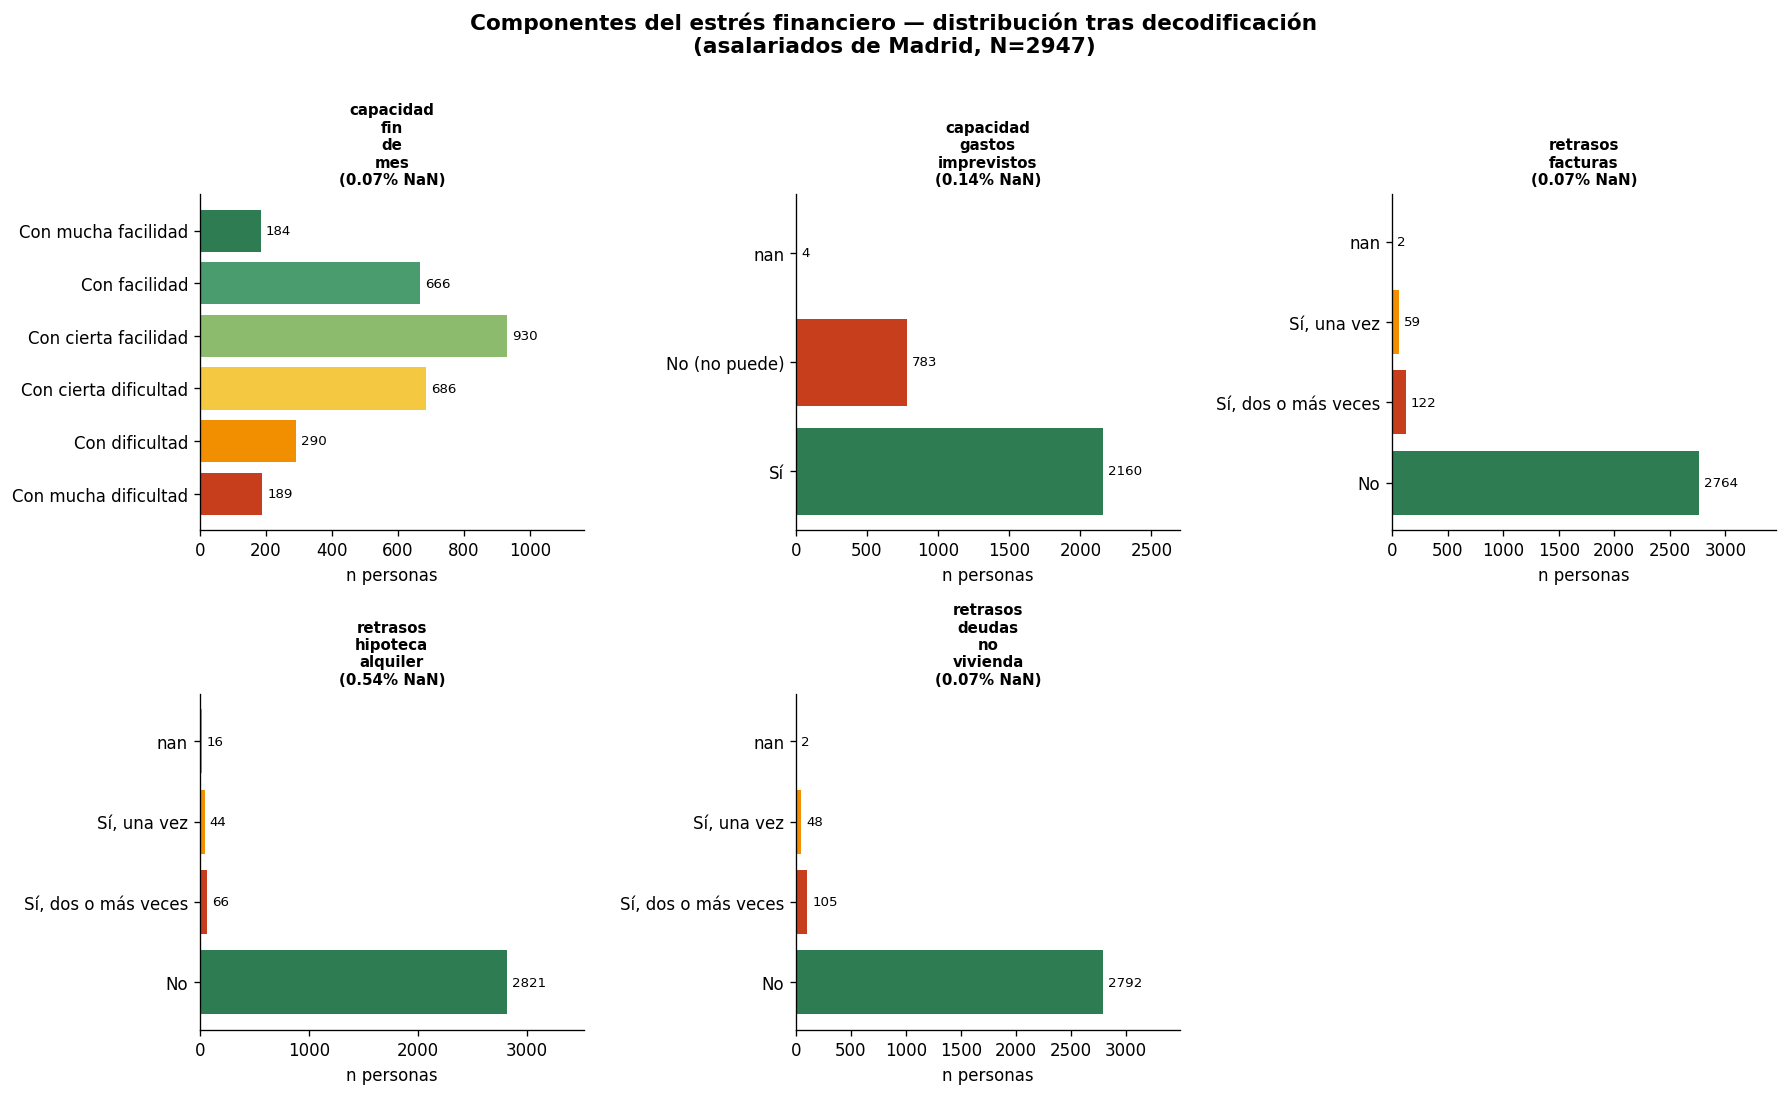

In [18]:
# Verificación visual: distribución de las 5 variables target tras decodificación
dis_target_descod(df)

### S.10 **Resumen del dataset analítico**

El dataset `dataset_analitico.csv` es el output de la capa Silver. Contiene **2.947 asalariados de la Comunidad de Madrid** con **64 variables limpias y documentadas**.


In [19]:
# Resumen final por grupos de variables
grupos = {
    'Identificadores y pesos': ['id_hogar', 'id_persona', 'peso_persona'],
    'Geografía': ['region', 'grado_urbanizacion'],
    'Demográficas': ['anio_nacimiento', 'edad', 'sexo', 'pais_nacimiento', 'nacionalidad'],
    'Situación laboral': ['situacion_actividad', 'situacion_profesional', 'horas_semana',
                         'jornada', 'tipo_contrato', 'personal_a_cargo', 'anios_experiencia',
                         'meses_desempleo_ref', 'meses_desempleo_5anios'],
    'Ocupación': ['ocupacion_isco08', 'sector_cnae'],
    'Educación': ['nivel_estudios'],
    'Salud': ['estado_salud', 'enfermedad_cronica', 'limitacion_actividad', 'necesito_medico_no_fue'],
    'Renta individual': ['renta_neta_salarial', 'renta_no_monetaria_salarial'],
    'Renta hogar': ['renta_neta_hogar', 'renta_hogar_indicadores', 'unidades_consumo',
                   'num_miembros_hogar', 'tipo_hogar'],
    'Pobreza y exclusión (hogar)': ['hogar_riesgo_pobreza', 'hogar_carencia_material'],
    'Componentes target (estrés)': ['retrasos_hipoteca_alquiler', 'retrasos_facturas',
                                    'retrasos_deudas_no_vivienda', 'capacidad_gastos_imprevistos',
                                    'capacidad_fin_de_mes'],
    'Privación material': ['puede_vacaciones', 'puede_proteina_2dias', 'tiene_ordenador',
                          'tiene_coche', 'carga_prestamos_no_vivienda', 'puede_sustituir_muebles',
                          'puede_calefaccion_invierno'],
    'Vivienda': ['tipo_vivienda', 'regimen_tenencia', 'num_habitaciones', 'importe_alquiler',
                'gastos_vivienda', 'cuota_hipoteca'],
    'Dinámica de ingresos': ['cambio_ingresos_12m', 'motivo_aumento_ingresos',
                             'motivo_disminucion_ingresos', 'expectativa_ingresos_12m'],
    'Carga sanitaria': ['carga_asistencia_medica', 'carga_asistencia_dental', 'carga_medicamentos'],
    'Variables derivadas INE': ['baja_intensidad_laboral_2020', 'arope_2020',
                                'carencia_material_social_severa', 'arope_2030'],
}

filas = []
for grupo, cols in grupos.items():
    for col in cols:
        if col in df.columns:
            nulos = df[col].isna().sum()
            dtype = str(df[col].dtype)
            filas.append({'Grupo': grupo, 'Variable': col,
                         'Tipo': dtype, 'Nulos': nulos,
                         '% Nulos': f'{nulos/len(df)*100:.1f}%'})

resumen_df = pd.DataFrame(filas)
print(f"Dataset analítico: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nInventario por grupos:")
print(resumen_df.to_string(index=False))


Dataset analítico: 2,947 filas × 64 columnas

Inventario por grupos:
                      Grupo                        Variable    Tipo  Nulos % Nulos
    Identificadores y pesos                        id_hogar   int64      0    0.0%
    Identificadores y pesos                      id_persona   int64      0    0.0%
    Identificadores y pesos                    peso_persona float64      0    0.0%
                  Geografía                          region     str      0    0.0%
                  Geografía              grado_urbanizacion     str      0    0.0%
               Demográficas                 anio_nacimiento   int64      0    0.0%
               Demográficas                            edad   int64      0    0.0%
               Demográficas                            sexo     str      0    0.0%
               Demográficas                 pais_nacimiento     str      0    0.0%
               Demográficas                    nacionalidad     str      0    0.0%
          Situació

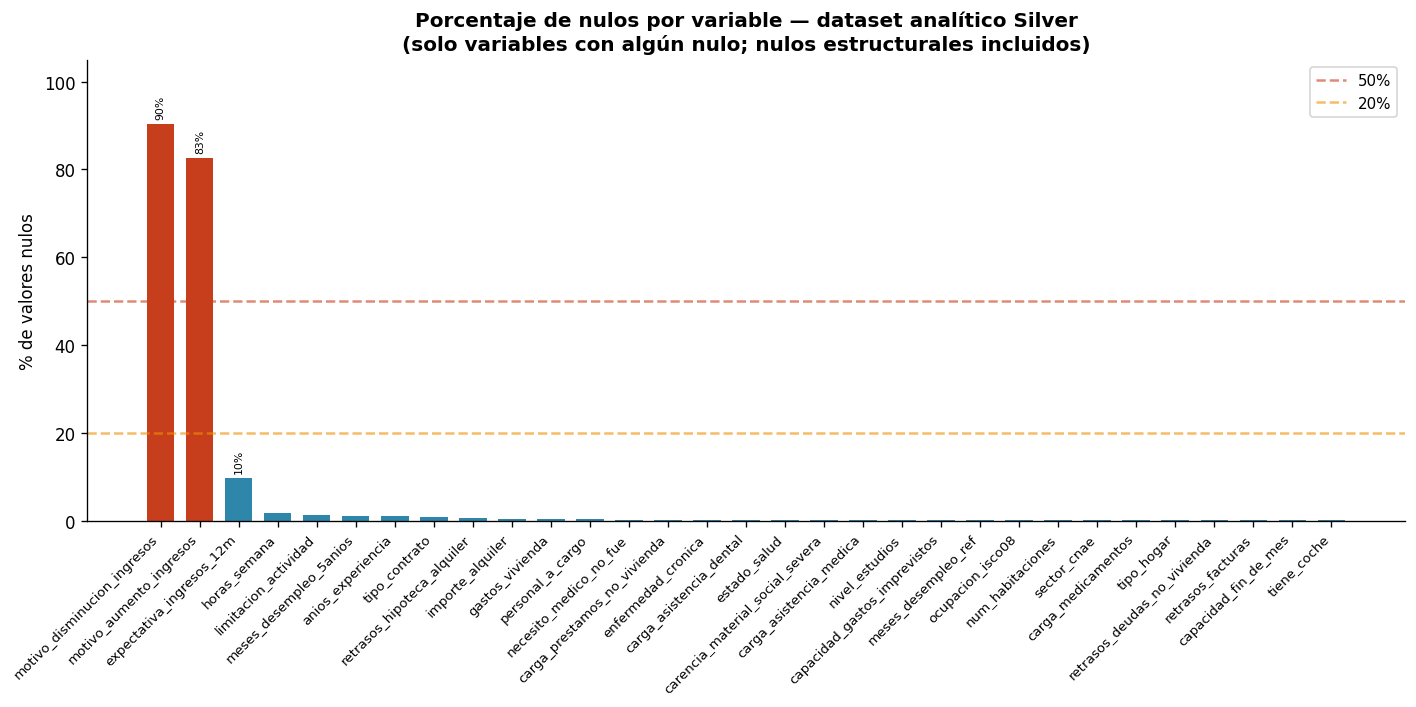


Nota: los nulos más elevados (HI030, HI020) son ESTRUCTURALES.
No responden a errores de datos sino a que la pregunta no aplica al perfil del encuestado.


In [20]:
# Mapa de calor de nulos por variable
dis_bar_nuls(df)


### S.11 **Exportación del dataset Silver**

El dataset analítico se guarda en `data/02_silver/dataset_analitico.csv`. Este es el punto de entrada para la capa Gold.

### S.12 **Decisiones de diseño — resumen**

La tabla siguiente consolida todas las decisiones tomadas durante la capa Silver, con su justificación. Sirve como referencia para la memoria del TFM y para auditar el pipeline.

| # | Ámbito | Decisión | Justificación |
|---|--------|----------|---------------|
| 1 | Arquitectura | Script `limpieza_ecv.py` separado del notebook | El script es el código de producción reproducible; el notebook documenta las decisiones para la memoria. Mantenerlos separados evita que la narrativa contamine la lógica ejecutable |
| 2 | Input | Partir de los CSVs originales del INE, no de los mapeados | Los CSVs mapeados tienen nombres largos que habría que volver a renombrar y columnas `_DESC` duplicadas que añaden ruido innecesario |
| 3 | Joins | `inner join` en todos los merges | La ECV garantiza cobertura completa para hogares y personas de la muestra; los registros huérfanos son inexistentes en la práctica |
| 4 | Filtro laboral | `PL040A` para identificar asalariados, no `PL040B` | `PL040A` recoge la situación profesional en el empleo **actual** (solo tiene valor si la persona trabaja); `PL040B` recoge el último empleo y solo tiene valores para inactivos y desempleados |
| 5 | Selección | Excluir rentas brutas (`PY010G`, `HY010`) | Redundantes con las netas (`PY010N`, `HY020`); incluir ambas introduciría multicolinealidad sin añadir información |
| 6 | Selección | Excluir variables `PL211*` (meses en cada situación mes a mes) | Son 12 columnas con alta correlación interna. `PL080` (meses en desempleo en año de referencia) y `PL271` (meses en desempleo en últimos 5 años) resumen suficientemente el historial |
| 7 | Selección | Excluir flags `_F` como features | Son metadatos de calidad del proceso de recogida, no información sustantiva del encuestado. Se usan en S.5 y se eliminan en S.6 |
| 8 | Imputación | Flag `-2` con semántica asignable → valor concreto (Grupo A) | Cuando "no aplica" equivale a una categoría real (ej. sin hipoteca → sin retrasos posibles → `'3'`/No), ignorarlo crearía NaN artificiales que distorsionarían el modelo. Se imputan 11 variables con este criterio |
| 9 | Imputación | Flag `-2` sin valor asignable → `NaN` estructural (Grupo B) | `HI020` y `HI030` (motivo del cambio de ingresos) solo existen si hubo cambio. No hay categoría que represente "no hubo cambio de ingresos", por lo que se deja como `NaN` |
| 10 | Imputación | Flag `-1` y `-6` → `NaN` en todos los flags (Grupo C) | `-1` = "no consta" (respuesta ausente real); `-6` = "no recogido por diseño muestral". Ambos son datos faltantes sin valor recuperable. La detección es automática sobre todos los flags seleccionados |
| 11 | Imputación | Alerta automática de flags `-2` no contemplados | Cualquier flag con `-2` en variables seleccionadas que no esté en el Grupo A o B se imprime explícitamente. Evita imputaciones silenciosas si en futuras ediciones de la ECV aparecen nuevas variables con este comportamiento |
| 12 | Nulos residuales | `PL060` trata `-1` y `-6` mediante su flag, no por detección de código negativo | `PL060` es la única variable numérica continua seleccionada con flag `-6`. Se gestiona explícitamente en el Grupo C para no depender de la limpieza genérica de nulos numéricos del paso S.9 |
| 13 | Geografía | Nivel de desagregación intramadrid limitado a `grado_urbanizacion` | El INE no publica municipio ni provincia en los microdatos públicos por razones de confidencialidad. `DB100` (muy poblada / media / poco poblada) es el máximo nivel disponible |
| 14 | Peso muestral | `peso_persona` conservado pero excluido del modelo | Se usa para estadísticas descriptivas ponderadas representativas de la población. No se incorpora como feature; su uso se documenta como limitación metodológica en la memoria |

---

**Próximo paso → Capa Gold:** construcción del target binario `estres_financiero_alto`, feature engineering, encoding de categóricas y estrategia de tratamiento de los NaN estructurales restantes según el algoritmo de modelado elegido.
